In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Module 1 Coding Task : Interatomic Interactions
"""
Calculates reduced potential energy and force magnitude for a pair
of atoms .
TASK : Use the equations to implement the Lennard - Jones potential and
force .
REQUIREMENTS :
1. Implement the shifted potential : phi (r) - phi (rc).
2. Return the force magnitude divided by r ( force /r).
"""
def calculate_lj_properties(r_sq, r_cutoff_sq):
    inv_rc2 = 1.0 / r_cutoff_sq
    inv_rc6 = inv_rc2**3
    inv_rc12 = inv_rc6**2
    phi_cut = 4 * (inv_rc12 - inv_rc6)
    
    inv_r2 = 1.0 / r_sq
    inv_r6 = inv_r2**3
    inv_r12 = inv_r6**2
    
    phi = 4 * (inv_r12 - inv_r6)
    

    potE = phi - phi_cut
    
    force_by_r = 48 * inv_r2 * (inv_r12 - 0.5 * inv_r6)

    return potE, force_by_r


In [3]:
def generate_fcc_lattice ( n_cells , rho_star ):

    """
    Generates an FCC lattice of atoms .
    TASK :
    1. Calculate the box length L based on density (rho = N/V).
    2. Place 4 atoms in each of the n_cells ^3 unit cells .
    """
    L = (4 * n_cells ** 3 / rho_star) ** (1 / 3)
    a = L / n_cells 
    b1 = np.array([0, 0, 0])
    b2 = np.array([a / 2, a / 2, 0])
    b3 = np.array([a / 2, 0, a / 2])
    b4 = np.array([0, a / 2, a / 2])
    positions = []
    for i in range(n_cells):
        for j in range(n_cells):
            for k in range(n_cells):
                cell_origin = np.array([i, j, k]) * (L / n_cells)
                positions.append(cell_origin + b1)
                positions.append(cell_origin + b2)
                positions.append(cell_origin + b3)
                positions.append(cell_origin + b4)

    return np.array(positions), L


# YOUR CODE HERE
def apply_minimum_image (pos_i , pos_j , L):
    """
    Calculates the shortest distance vector between two atoms .
    TASK : Use the rounding logic to ensure dx ,
    dy , and dz
    are between -L/2 and L/2.
    """
    dr = pos_j - pos_i
    dr -= L * np.round(dr / L)
    return dr

In [4]:
def calculate_total_force(pos, box_length, r_cutoff_sq):
    N = len(pos)
    forces = np.zeros((N, 3))
    total_pe = 0

    for i in range(N - 1):
        for j in range(i + 1, N):
            dr = apply_minimum_image(pos[i], pos[j], box_length)
            r_sq = np.dot(dr, dr)
            if r_sq<r_cutoff_sq:
                pot, force_by_r = calculate_lj_properties(r_sq, r_cutoff_sq)
                f_vec = force_by_r * dr
                forces[i] -= f_vec
                forces[j] += f_vec
                total_pe += pot

    return total_pe, forces


# Module 3 Coding Task : The Integration Engine
def velocity_verlet_step(pos, vel, force, dt, box_length, r_cutoff_sq):
    """
    Advances the system by one time step dt using Velocity Verlet.
    TASK :
    1. Update positions .
    2. Apply Periodic Boundary Conditions ( wrap atoms back into box ).
    3. Update velocities (half - step ).
    4. Calculate new forces ( This will require your Module 1 & 2 logic ).
    5. Update velocities (full - step ).
    """
    # YOUR CODE HERE

    # Step 1: New Positions
    pos_new = pos + vel * dt + 0.5 * force * dt**2
    # Step 2: PBC Wrap ( Module 2 logic )
    pos_new = pos_new % box_length
    # Step 3: Half - step velocity
    vel_mid = vel + 0.5 * force * dt
    # Step 4: New Forces ( Call your Module 1 force function here )
    pe_new, force_new = calculate_total_force(pos_new, box_length, r_cutoff_sq)
    # Step 5: Full - step velocity
    vel_new = vel_mid + 0.5 * force_new * dt

    return pos_new, vel_new, pe_new, force_new

Mean E: -481.3507 | Std: 0.001255 | Relative drift: 2.61e-06


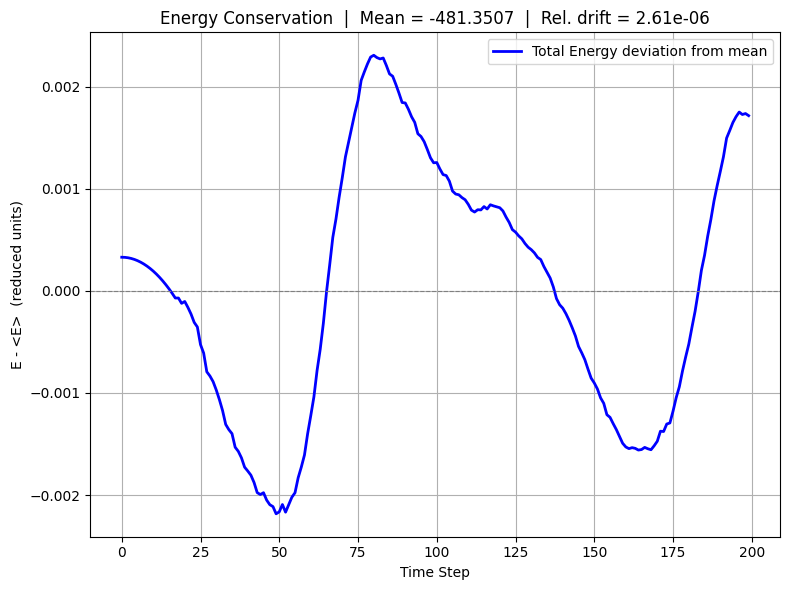

In [5]:
def calculate_kinetic_energy(vel):
    return 0.5 * np.sum(vel**2)

n_cells = 3
rho_star = 0.8
dt = 1e-3
r_cutoff_sq = 2.5**2

pos, L = generate_fcc_lattice(n_cells, rho_star)
vel = np.random.randn(*pos.shape) * np.sqrt(1.0)
vel -= vel.mean(axis=0)

pe, force = calculate_total_force(pos, L, r_cutoff_sq)

energies = []
for step in range(200):
    pos, vel, pe, force = velocity_verlet_step(pos, vel, force, dt, L, r_cutoff_sq)
    ke = calculate_kinetic_energy(vel)
    energies.append(ke + pe)

E = np.array(energies)
print(f"Mean E: {E.mean():.4f} | Std: {E.std():.6f} | Relative drift: {E.std()/abs(E.mean()):.2e}")
steps = np.arange(len(E))

plt.figure(figsize=(8, 6))
E = np.array(energies)
E_mean = E.mean()
E_deviation = E - E_mean

plt.plot(steps, E_deviation, color='blue', linewidth=2, label='Total Energy deviation from mean')

plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.xlabel('Time Step')
plt.ylabel('E - <E>  (reduced units)')
plt.title(f'Energy Conservation  |  Mean = {E_mean:.4f}  |  Rel. drift = {E.std()/abs(E_mean):.2e}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Mean Total Energy: 0.049095
Standard Deviation: 0.000163
Relative Drift: 3.33e-03


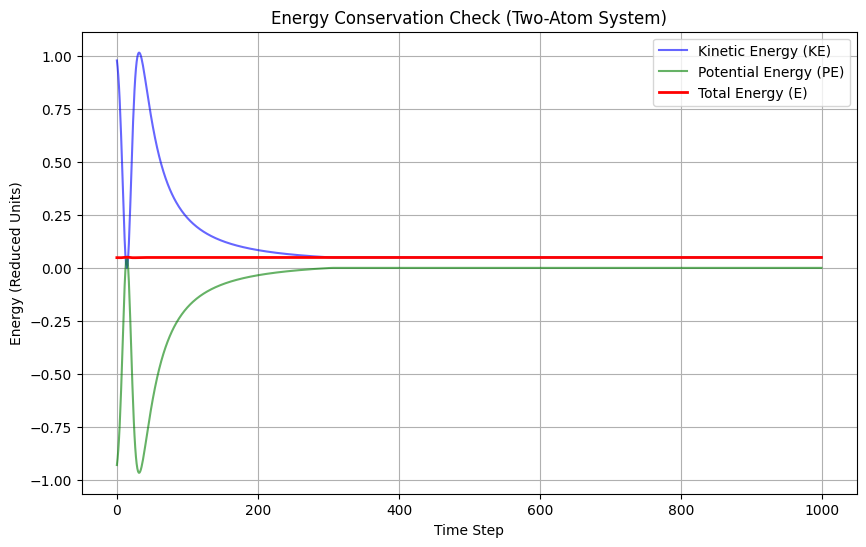

In [6]:
L = 10.0
r_cutoff_sq = L/2
dt = 0.005
n_steps = 1000

pos = np.array([
    [4.5, 5.0, 5.0],
    [5.6, 5.0, 5.0]
])
vel = np.array([
    [1.0, 0.0, 0.0],
    [-1.0, 0.0, 0.0]
])

pe, force = calculate_total_force(pos, L, r_cutoff_sq)

ke_list = []
pe_list = []
total_e_list = []

for step in range(n_steps):
    pos, vel, pe, force = velocity_verlet_step(pos, vel, force, dt, L, r_cutoff_sq)
    ke = calculate_kinetic_energy(vel)
    ke_list.append(ke)
    pe_list.append(pe)
    total_e_list.append(ke + pe)

plt.figure(figsize=(10, 6))
plt.plot(ke_list, label='Kinetic Energy (KE)', color='blue', alpha=0.6)
plt.plot(pe_list, label='Potential Energy (PE)', color='green', alpha=0.6)
plt.plot(total_e_list, label='Total Energy (E)', color='red', linewidth=2)

plt.title('Energy Conservation Check (Two-Atom System)')
plt.xlabel('Time Step')
plt.ylabel('Energy (Reduced Units)')
plt.legend()
plt.grid(True)

E = np.array(total_e_list)
rel_drift = E.std() / np.abs(E.mean())
print(f"Mean Total Energy: {E.mean():.6f}")
print(f"Standard Deviation: {E.std():.6f}")
print(f"Relative Drift: {rel_drift:.2e}")

plt.show()